# Using SGU wells

This notebook demonstrates the use of the python package `sgu-client` and how to integrate with `gwrefpy`. The package is installed along with `gwrefpy` if recommened add-ons are included: `pip install "gwrefpy[recommended]"`

The Geological Survey of Sweden (SGU) serves an API for their groundwater monitoring network. A Python implementation of an API client has been developed in [`sgu-client`](https://github.com/officialankan/sgu-client) which makes getting observed groundwater levels from SGU into Python a breeze. 



```{note}
The `sgu-client` package is not affiliated with, supported or endorsed by SGU.
```

In [66]:
import gwrefpy as gr
from sgu_client import SGUClient
import warnings

warnings.filterwarnings("ignore")
gr.set_log_level("ERROR")

## Getting observed groundwater levels

This basic example will show how to fetch observed groundwater levels. For more options, please refer to [these docs](https://github.com/officialankan/sgu-client?tab=readme-ov-file#observed-groundwater-levels).

Below, we wrangle the data in two steps:

1. remove the UTC timezone from the fetched timeseries to achieve compatability with the example model we will load later,
2. resample to daily medians to align the frequency with that of the example model we will load later

<Axes: xlabel='observation_date'>

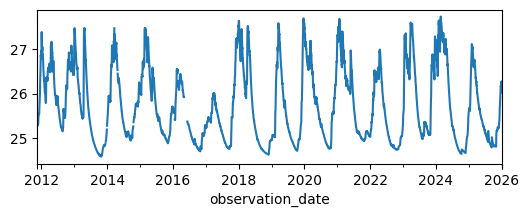

In [73]:
with SGUClient() as client:
    lagga_levels = client.levels.observed.get_measurements_by_name("95_2").to_series()

lagga_levels.index = lagga_levels.index.tz_convert(None) 
lagga_levels = lagga_levels.resample("1D").median()

_ = lagga_levels.plot(figsize=(6, 2))

## Inserting as a reference well in a `Model`

For this basic demonstration, we will load a tutorial model and add our newly fetched SGU well as a reference well.

In [74]:
model = gr.Model("deviation_example.gwref")
model.wells_summary()

,name,well_type,data_points,start_date,end_date,mean_level,latest_value,latest_date,latitude,longitude,elevation,best_fit_ref_well,best_rmse,num_fits,avg_rmse
0,19W110U,observation,2824,2018-01-01,2025-09-24,25.657419,24.949029,2025-09-24,None,None,None,None,None,NaN,NaN
1,19W100U,reference,2824,2018-01-01,2025-09-24,25.757644,24.873000,2025-09-24,None,None,None,NaN,NaN,0.0,None


In [75]:
well_object = gr.Well("95_2", is_reference=True, timeseries=lagga_levels)
model.add_well(well_object)

model.fit("19W110U", "95_2", offset="0D")  # both are sampled daily

2026-01-08 15:20:39,812 - gwrefpy.methods.linregressfit - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 15:20:39,813 - gwrefpy.methods.linregressfit - WARNING - tmax is None, setting to max common time of both wells


Statistic,Value,Description
RMSE,0.3025,Root Mean Square Error
R²,0.8736,Coefficient of Determination
R-value,0.9346,Correlation Coefficient
Slope,0.9033,Linear Regression Slope
Intercept,2.3905,Linear Regression Intercept
P-value,0.0000,Statistical Significance
N,2824,Number of Data Points
Std Error,0.3026,Standard Error
Confidence,95.0%,Confidence Level


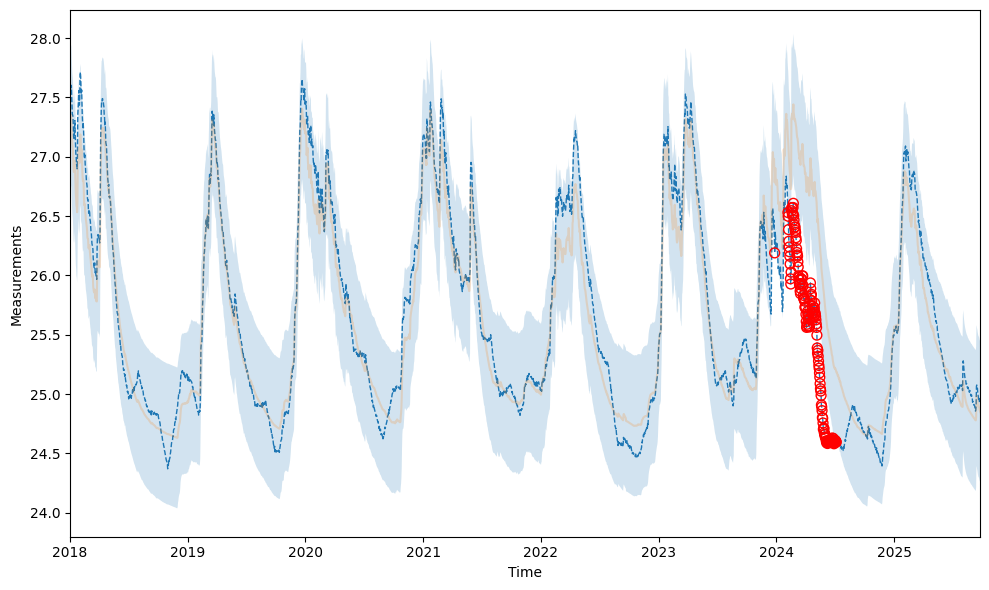

In [77]:
_ = model.plot_fits()

This concludes a very basic demonstration on integrating `sgu-client` and `gwrefpy`. Associated workflows will likely benefit from looking at our capabilities on [appending data to a reference well](https://sgfsweden.github.io/gwrefpy/tutorials/livedata.html).

Happy monitoring and big thanks to SGU for their impressive monitoring network.